In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("AirPassengers.csv",parse_dates=["Month"],index_col="Month")

In [4]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [5]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [8]:
df.rename(columns={"#Passengers":"Passengers"},inplace=True)

In [10]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


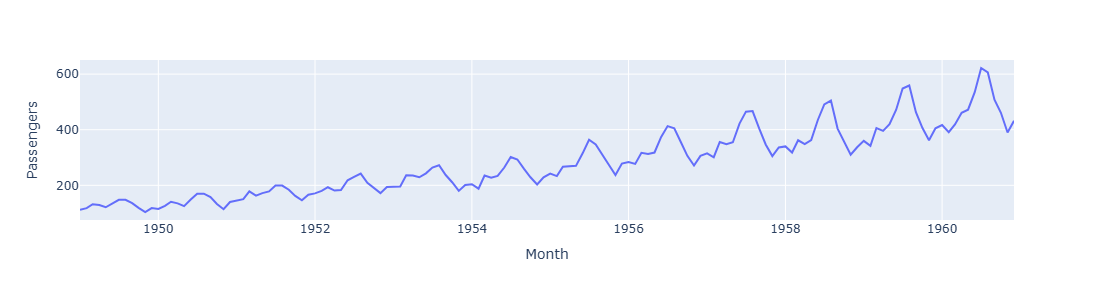

In [17]:
#Using Plotly Express
fig=px.line(
    df,
    x=df.index,
    y=df["Passengers"],
    labels={"Month":"Month","Passengers":"Passengers"}
)
fig.update_layout(
    width=1000,
    height=300
)
fig.show()

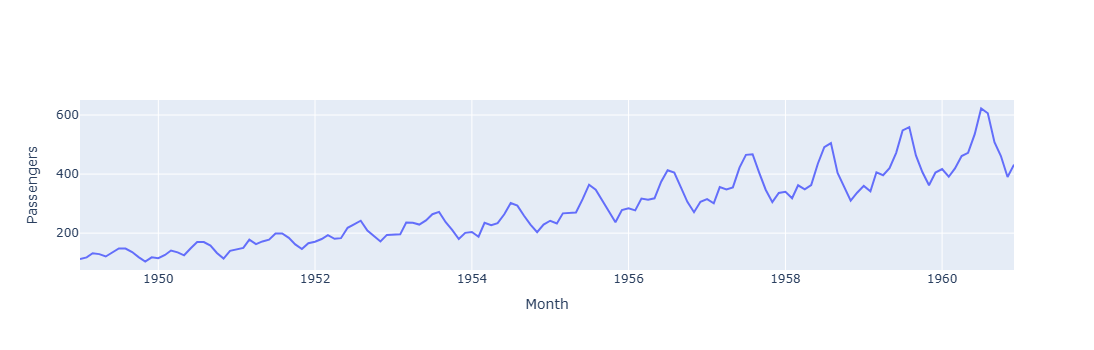

In [16]:
# Using Graph Objects
import plotly.graph_objects as go 
fig=go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Passengers"],
        mode="lines",
        name="Passengers"
    ))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Passengers",
    width=1000,
    height=350)
fig.show()

In [21]:
monthly_avg=df.groupby(df.index.month)["Passengers"].mean()
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

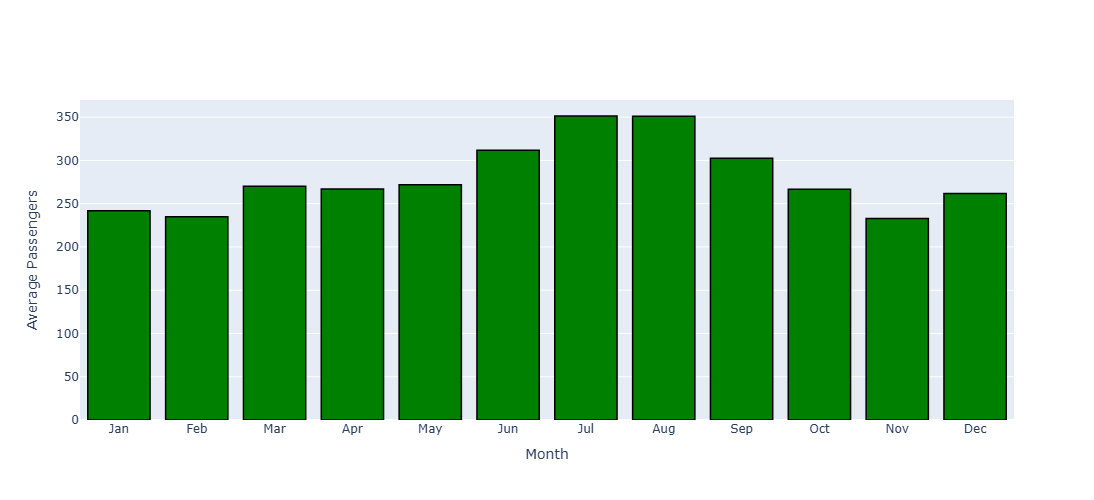

In [27]:
import plotly.graph_objects as go
fig=go.Figure()
fig.add_trace(go.Bar(
    x=month_names,
    y=monthly_avg.values,
    marker_color="green",
    marker_line_color="black",
    marker_line_width=1.5))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Average Passengers",
    width=1000,
    height=500
)
fig.show()

In [18]:
df_diff=df[["Passengers"]].diff().dropna()

In [19]:
df_diff.head()

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0


In [31]:
# Finding the d value
from statsmodels.tsa.stattools import adfuller

In [32]:
res=adfuller(df_diff["Passengers"])
print("Adf Statatics:",res[0])
print("P-Value:",res[1])

Adf Statatics: -2.8292668241699994
P-Value: 0.0542132902838255


In [33]:
df_diff2=df[["Passengers"]].diff(2).dropna()

In [35]:
res=adfuller(df_diff2["Passengers"])
print("Adf Statatics:",res[0])
print("P-Value:",res[1])

## D Value->Difference value is 2 

Adf Statatics: -2.9616951355554244
P-Value: 0.03862975767698839


In [36]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

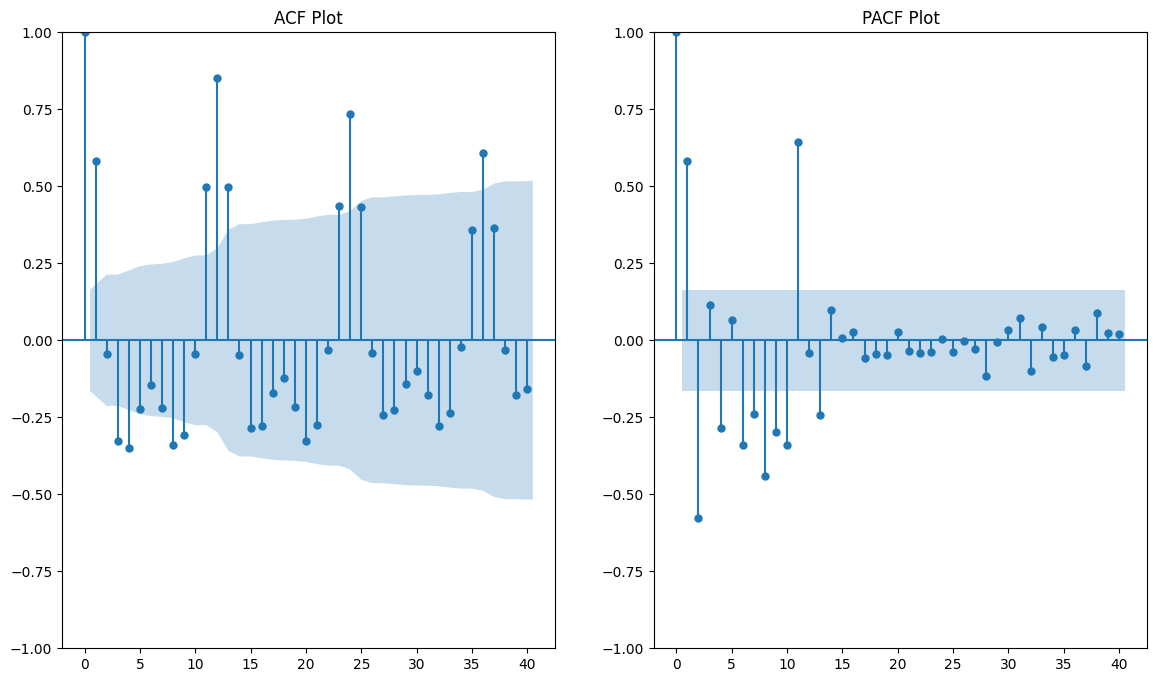

In [41]:
fig,axes=plt.subplots(1,2,figsize=(14,8))
plot_acf(df_diff2["Passengers"],lags=40,ax=axes[0])
axes[0].set_title("ACF Plot")
plot_pacf(df_diff2["Passengers"],lags=40,ax=axes[1])
axes[1].set_title("PACF Plot")
plt.show()

In [42]:
#Training Data-1949-1954
#Testing data-1955-1960
train=df.loc["1949":"1954"]
test=df.loc["1955":"1960"]

In [43]:
train

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1954-08-01,293
1954-09-01,259
1954-10-01,229


In [44]:
test

,Passengers
Month,
1955-01-01,242
1955-02-01,233
1955-03-01,267
1955-04-01,269
1955-05-01,270
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [45]:
train.shape

(72, 1)

In [46]:
test.shape

(72, 1)

In [48]:
# Arima Model
from statsmodels.tsa.arima.model import ARIMA

In [49]:
model=ARIMA(train["Passengers"],order=(1,2,1))
model_arima=model.fit()
print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                   72
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -307.175
Date:                Mon, 02 Mar 2026   AIC                            620.349
Time:                        09:58:54   BIC                            627.095
Sample:                    01-01-1949   HQIC                           623.028
                         - 12-01-1954                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1890      0.166      1.141      0.254      -0.136       0.514
ma.L1         -0.9990      3.887     -0.257      0.797      -8.617       6.620
sigma2       359.2089   1414.352      0.254      0.8

In [50]:
arima_forecast=model_arima.forecast(steps=len(test))
print(arima_forecast)

1955-01-01    235.325635
1955-02-01    237.933482
1955-03-01    239.838792
1955-04-01    241.611347
1955-05-01    243.358816
                 ...    
1960-08-01    353.082468
1960-09-01    354.824092
1960-10-01    356.565715
1960-11-01    358.307339
1960-12-01    360.048963
Freq: MS, Name: predicted_mean, Length: 72, dtype: float64


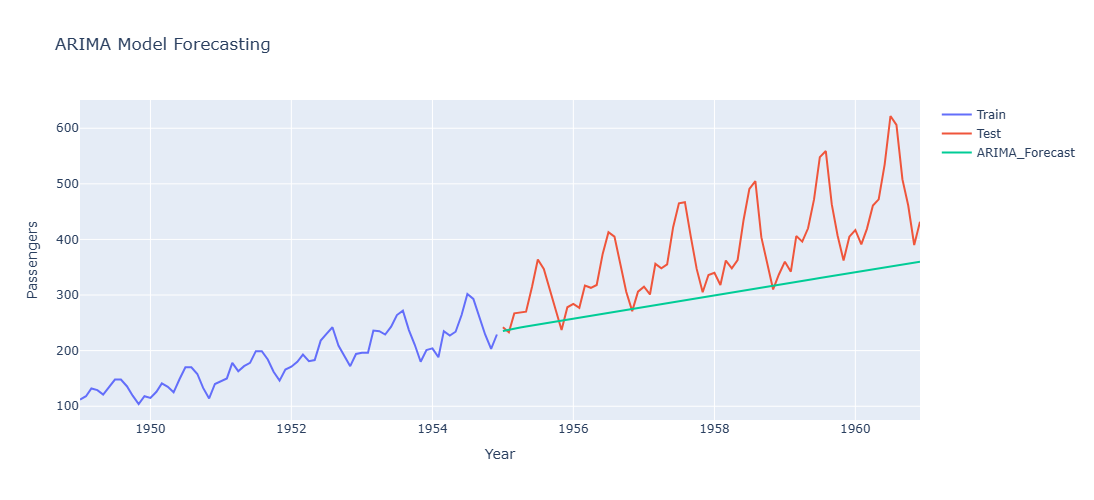

In [52]:
## Ploting arima
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA_Forecast"))
fig.update_layout(
    title="ARIMA Model Forecasting",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500)
fig.show()

In [53]:
#SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [62]:
model=SARIMAX(
    train["Passengers"],
    order=(1,2,1),
    seasonal_order=(1,2,1,12)
)
model_sarima=model.fit()
print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                   72
Model:             SARIMAX(1, 2, 1)x(1, 2, 1, 12)   Log Likelihood                -182.311
Date:                            Mon, 02 Mar 2026   AIC                            374.623
Time:                                    10:22:45   BIC                            383.766
Sample:                                01-01-1949   HQIC                           378.048
                                     - 12-01-1954                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3740      0.162     -2.311      0.021      -0.691      -0.057
ma.L1         -0.9957      3.007   

In [63]:
sarima_forecast=model_sarima.forecast(len(test))
print(sarima_forecast)

1955-01-01    229.931883
1955-02-01    214.583959
1955-03-01    267.635235
1955-04-01    261.583196
1955-05-01    265.261513
                 ...    
1960-08-01    250.395325
1960-09-01    175.820553
1960-10-01    125.573014
1960-11-01     72.984310
1960-12-01     99.791939
Freq: MS, Name: predicted_mean, Length: 72, dtype: float64


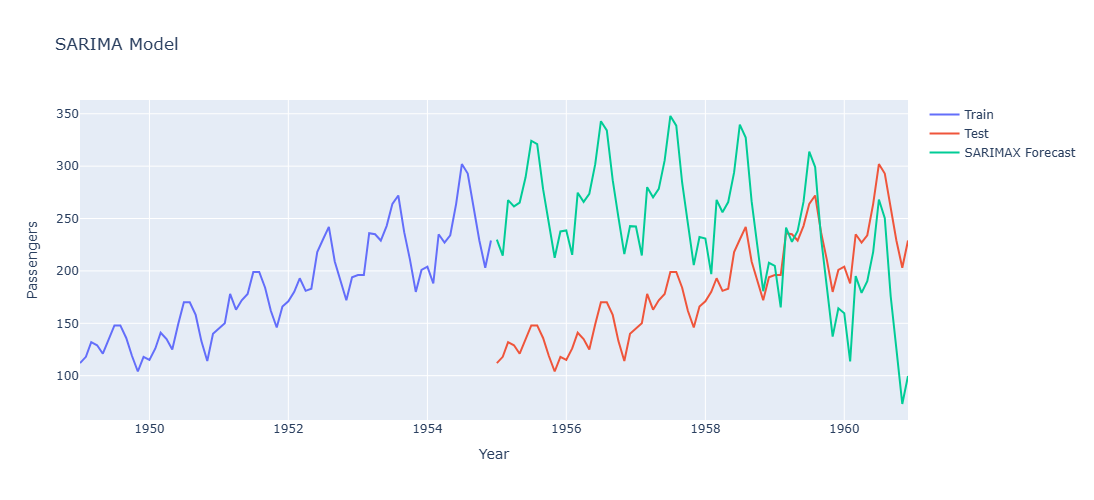

In [64]:
##Ploting SARIMAX
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=train["Passengers"],
    mode="lines",
    name="Test"
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMAX Forecast"))
fig.update_layout(
    title="SARIMA Model",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500)
fig.show()

In [66]:
##Prophet Model
from prophet import Prophet
train_prophet=train.reset_index()
train_prophet.columns=["ds","y"]

In [67]:
prophet_model=Prophet(
    seasonality_mode='multiplicative',  
    yearly_seasonality=True,
    weekly_seasonality=False,    
    daily_seasonality=False,     
    changepoint_prior_scale=0.05,  
    seasonality_prior_scale=10     
)


In [70]:
prophet_model.fit(train_prophet)

10:33:56 - cmdstanpy - INFO - Chain [1] start processing
10:33:59 - cmdstanpy - INFO - Chain [1] done processing


In [73]:
future = prophet_model.make_future_dataframe(periods=len(test), freq="MS")
prophet_forecast = prophet_model.predict(future)

In [74]:
print(prophet_forecast)

            ds       trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0   1949-01-01  119.892146  100.413691  116.132138   119.892146   119.892146   
1   1949-02-01  121.052741  100.279212  115.195994   121.052741   121.052741   
2   1949-03-01  122.101021  119.819744  136.229082   122.101021   122.101021   
3   1949-04-01  123.261616  115.292330  131.874275   123.261616   123.261616   
4   1949-05-01  124.384773  114.508804  129.768495   124.384773   124.384773   
..         ...         ...         ...         ...          ...          ...   
139 1960-08-01  364.359089  410.298262  472.678278   340.619158   390.099915   
140 1960-09-01  366.050970  350.213688  407.348333   341.788209   392.104547   
141 1960-10-01  367.688274  315.535890  367.366072   342.843302   394.266887   
142 1960-11-01  369.380155  275.576786  321.611833   343.930790   396.590405   
143 1960-12-01  371.017458  309.028813  362.083076   345.192471   398.881546   

     multiplicative_terms  multiplicati

In [75]:
forecast_test = forecast.tail(len(test))

In [76]:
forecast_test

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
72,1955-01-01,253.077004,220.496952,236.534290,253.053961,253.101877,-0.096636,-0.096636,-0.096636,-0.096636,-0.096636,-0.096636,0.0,0.0,0.0,228.620697
73,1955-02-01,254.768885,223.304765,238.747009,254.684334,254.867474,-0.091573,-0.091573,-0.091573,-0.091573,-0.091573,-0.091573,0.0,0.0,0.0,231.438829
74,1955-03-01,256.297035,259.341797,275.012622,256.116605,256.488542,0.041894,0.041894,0.041894,0.041894,0.041894,0.041894,0.0,0.0,0.0,267.034303
75,1955-04-01,257.988916,244.890374,261.054944,257.686326,258.305911,-0.019095,-0.019095,-0.019095,-0.019095,-0.019095,-0.019095,0.0,0.0,0.0,253.062672
76,1955-05-01,259.626220,252.282999,267.426657,259.202222,260.110421,0.001158,0.001158,0.001158,0.001158,0.001158,0.001158,0.0,0.0,0.0,259.926944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,364.359089,408.480700,470.830223,339.475064,389.708606,0.205812,0.205812,0.205812,0.205812,0.205812,0.205812,0.0,0.0,0.0,439.348637
140,1960-09-01,366.050970,349.280093,405.906850,340.451683,392.079307,0.030753,0.030753,0.030753,0.030753,0.030753,0.030753,0.0,0.0,0.0,377.308008
141,1960-10-01,367.688274,313.541703,366.608709,341.457775,394.362702,-0.075322,-0.075322,-0.075322,-0.075322,-0.075322,-0.075322,0.0,0.0,0.0,339.993147
142,1960-11-01,369.380155,274.670851,320.562243,342.667527,396.668070,-0.193087,-0.193087,-0.193087,-0.193087,-0.193087,-0.193087,0.0,0.0,0.0,298.057546


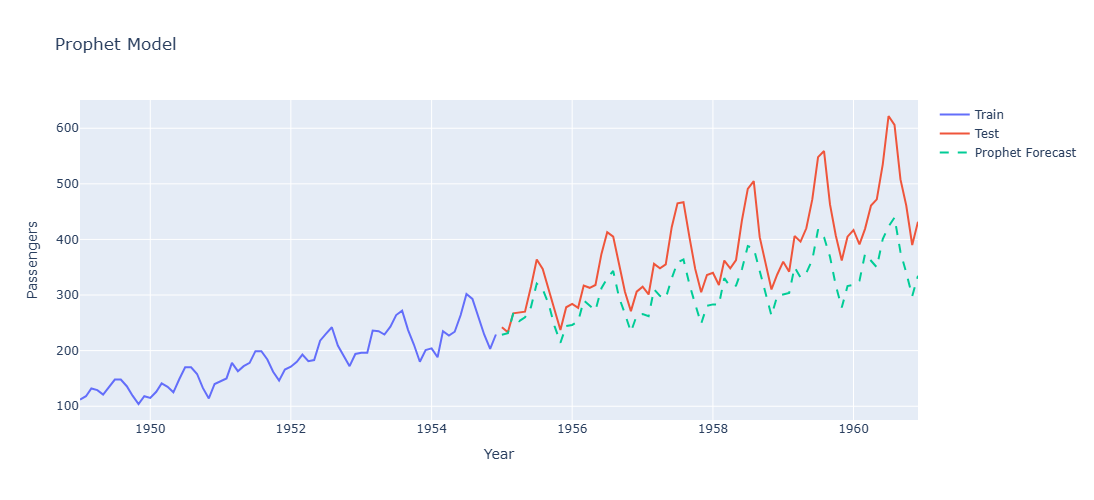

In [80]:
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"
))
fig.add_trace(go.Scatter(
    x=forecast_test["ds"],
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet Forecast",
    line=dict(dash="dash"))
             )
fig.update_layout(title="Prophet Model",
                  xaxis_title="Year",
                  yaxis_title="Passengers",
                  width=1000,
                  height=500)
fig.show()

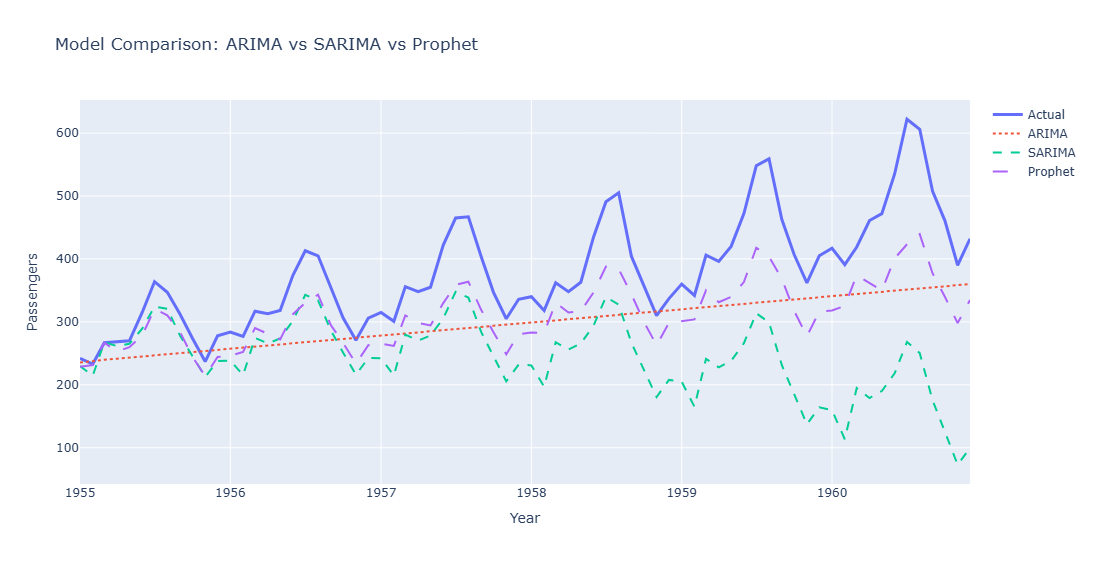

In [89]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual",
    line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA",
    line=dict(dash="dot")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMA",
    line=dict(dash="dash")
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet",
    line=dict(dash="longdash")
))

fig.update_layout(
    title="Model Comparison: ARIMA vs SARIMA vs Prophet",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1100,
    height=550
)

fig.show()

In [85]:
comparsion_df=pd.DataFrame({
    "Date":test.index,
    "Actual":test["Passengers"].values,
    "ARIMA":arima_forecast,
    "SARIMA":sarima_forecast,
    "Prophet":forecast_test["yhat"].values
})
comparsion_df.set_index("Date",inplace=True)


In [86]:
comparsion_df

,Actual,ARIMA,SARIMA,Prophet
Date,,,,
1955-01-01,242,235.325635,229.931883,228.620697
1955-02-01,233,237.933482,214.583959,231.438829
1955-03-01,267,239.838792,267.635235,267.034303
1955-04-01,269,241.611347,261.583196,253.062672
1955-05-01,270,243.358816,265.261513,259.926944
...,...,...,...,...
1960-08-01,606,353.082468,250.395325,439.348637
1960-09-01,508,354.824092,175.820553,377.308008
1960-10-01,461,356.565715,125.573014,339.993147


In [88]:
comparsion_df.to_csv("model_comparison.csv")